In [18]:
import pandas as pd
import numpy as np
from pathlib import Path
import re
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

In [19]:
# Define objective function for c=1.5
def f_rosenbrock(theta, c=1.5):
    """
    Rosenbrock 1D function:
    f(theta) = (1 - theta)^2 + c*(theta^2 - 1)^2
    """
    return (1 - theta)**2 + c * (theta**2 - 1)**2

def extract_params(filename):
    """Extract parameters from filename"""

    # For discrete files: c_X.X_results_initial_theta_Y_lr_Z_beta1_W_beta2_V.csv
    match_discrete = re.search(
        r'c_([\d.]+)_results_initial_theta_([-\d.]+)_lr_([\d.]+)_beta1_([\d.]+)_beta2_([\d.]+)\.csv',
        filename
    )
    if match_discrete:
        return {
            'c': float(match_discrete.group(1)),
            'initial_theta': float(match_discrete.group(2)),
            'initial_velocity': None,
            'lr': float(match_discrete.group(3)),
            'beta1': float(match_discrete.group(4)),
            'beta2': float(match_discrete.group(5))
        }

    # For 2nd order: second_order_c_X.X_initial_theta_Y_initial_velocity_Z_lr_W_beta1_V_beta2_U.csv
    match_2nd_order = re.search(
        r'second_order_c_([\d.]+)_initial_theta_([-\d.]+)_initial_velocity_([-\d.]+)_lr_([\d.]+)_beta1_([\d.]+)_beta2_([\d.]+)\.csv',
        filename
    )
    if match_2nd_order:
        return {
            'c': float(match_2nd_order.group(1)),
            'initial_theta': float(match_2nd_order.group(2)),
            'initial_velocity': float(match_2nd_order.group(3)),
            'lr': float(match_2nd_order.group(4)),
            'beta1': float(match_2nd_order.group(5)),
            'beta2': float(match_2nd_order.group(6))
        }

    # For 1st order: first_order_c_X.X_initial_theta_Y_initial_velocity_Z_lr_W_beta1_V_beta2_U.csv
    match_1st_order = re.search(
        r'first_order_c_([\d.]+)_initial_theta_([-\d.]+)_initial_velocity_([-\d.]+)_lr_([\d.]+)_beta1_([\d.]+)_beta2_([\d.]+)\.csv',
        filename
    )
    if match_1st_order:
        return {
            'c': float(match_1st_order.group(1)),
            'initial_theta': float(match_1st_order.group(2)),
            'initial_velocity': float(match_1st_order.group(3)),  # usually 0.0 for 1st order
            'lr': float(match_1st_order.group(4)),
            'beta1': float(match_1st_order.group(5)),
            'beta2': float(match_1st_order.group(6))
        }

    return None

def calculate_errors_time_aligned(theta_discrete, theta_continuous,
                                  c=1.5, alpha=None, T=None, delta=0.0,
                                  dt_continuous=None):
    """
    Compare theta_k (discrete at t_k = k*alpha) with theta_continuous sampled on its own grid.
    Continuous values are interpolated onto the discrete times.
    """
    if alpha is None:
        raise ValueError("alpha must be provided (discrete step size).")
    if dt_continuous is None:
        dt_continuous = alpha  # continuous stored on same grid by default

    theta_d = np.asarray(theta_discrete, dtype=float)
    theta_c = np.asarray(theta_continuous, dtype=float)

    if len(theta_d) == 0 or len(theta_c) == 0:
        raise ValueError("Input sequences are empty")

    t_d = np.arange(len(theta_d)) * alpha
    t_c = np.arange(len(theta_c)) * dt_continuous

    # Time window
    if T is None:
        T_used = min(t_d[-1], t_c[-1])
    else:
        T_used = min(T, t_d[-1], t_c[-1])

    if delta >= T_used:
        raise ValueError(f"delta={delta} must be < T_used={T_used}.")

    mask = (t_d >= delta) & (t_d <= T_used)
    t_eval = t_d[mask]
    theta_d_eval = theta_d[mask]

    # Interpolate continuous onto discrete times (no extrapolation)
    interp_c = interp1d(t_c, theta_c, kind="cubic", bounds_error=True)
    theta_c_eval = interp_c(t_eval)

    E_inf = np.max(np.abs(theta_d_eval - theta_c_eval))

    f_d = f_rosenbrock(theta_d_eval, c=c)
    f_c = f_rosenbrock(theta_c_eval, c=c)
    E_f = np.max(np.abs(f_d - f_c))

    info = {
        "T_used": float(T_used),
        "n_points": int(len(t_eval)),
        "alpha": float(alpha),
        "dt_continuous": float(dt_continuous),
        "delta": float(delta),
    }
    return E_inf, E_f, info

def estimate_p(alphas, errors):
    """Fit log-log slope: errors ≈ C * alpha^p."""
    alphas = np.asarray(alphas, dtype=float)
    errors = np.asarray(errors, dtype=float)

    mask = np.isfinite(alphas) & np.isfinite(errors) & (alphas > 0) & (errors > 0)
    x = np.log(alphas[mask])
    y = np.log(errors[mask])

    p, logC = np.polyfit(x, y, 1)
    C = np.exp(logC)
    return float(p), float(C)

In [20]:
# Configuration: theta_initial = -1.5, fixed betas
target_initial_theta = -1.5
target_beta1 = 0.99
target_beta2 = 0.999
c_value = 1.5

T_horizon = 10
delta_burnin = 1

# Continuous integration uses substeps h = alpha/5
SUBSTEP_FACTOR = 5  # dt_continuous = alpha / SUBSTEP_FACTOR

# Directories
results_dir = Path("results")
results_1st_order_dir = Path("results_1rst_order")
results_2nd_order_dir = Path("results_2nd_order")

In [21]:
# Read ALL discrete files
discrete_data_dict = {}
discrete_files = list(results_dir.glob("*.csv"))

for csv_file in discrete_files:
    params = extract_params(str(csv_file))
    if (params and
        params['c'] == c_value and
        params['initial_theta'] == target_initial_theta and
        params['beta1'] == target_beta1 and
        params['beta2'] == target_beta2):
        lr = params['lr']
        discrete_data_dict[lr] = pd.read_csv(csv_file)
        print(f"Discrete file found: {csv_file.name}, lr={lr}")

# Read 1st order files
results_1st_order = {}
continuous_1st_files = list(results_1st_order_dir.glob("*.csv"))

for csv_file in continuous_1st_files:
    params = extract_params(str(csv_file))
    if (params and
        params['c'] == c_value and
        params['initial_theta'] == target_initial_theta and
        params['beta1'] == target_beta1 and
        params['beta2'] == target_beta2):
        lr = params['lr']
        results_1st_order[lr] = pd.read_csv(csv_file)
        print(f"1st order file found: {csv_file.name}, lr={lr}")

# Read 2nd order files
results_2nd_order = {}
continuous_2nd_files = list(results_2nd_order_dir.glob("*.csv"))

for csv_file in continuous_2nd_files:
    params = extract_params(str(csv_file))
    if (params and
        params['c'] == c_value and
        params['initial_theta'] == target_initial_theta and
        params['beta1'] == target_beta1 and
        params['beta2'] == target_beta2):
        lr = params['lr']
        v0 = params['initial_velocity']

        if lr not in results_2nd_order:
            results_2nd_order[lr] = {}
        results_2nd_order[lr][v0] = pd.read_csv(csv_file)
        print(f"2nd order file found: {csv_file.name}, lr={lr}, v0={v0}")

Discrete file found: c_1.5_results_initial_theta_-1.5_lr_0.01_beta1_0.99_beta2_0.999.csv, lr=0.01
Discrete file found: c_1.5_results_initial_theta_-1.5_lr_0.05_beta1_0.99_beta2_0.999.csv, lr=0.05
Discrete file found: c_1.5_results_initial_theta_-1.5_lr_0.0005_beta1_0.99_beta2_0.999.csv, lr=0.0005
Discrete file found: c_1.5_results_initial_theta_-1.5_lr_0.005_beta1_0.99_beta2_0.999.csv, lr=0.005
Discrete file found: c_1.5_results_initial_theta_-1.5_lr_0.001_beta1_0.99_beta2_0.999.csv, lr=0.001
1st order file found: first_order_c_1.5_initial_theta_-1.5_initial_velocity_0.0_lr_0.05_beta1_0.99_beta2_0.999.csv, lr=0.05
1st order file found: first_order_c_1.5_initial_theta_-1.5_initial_velocity_0.0_lr_0.01_beta1_0.99_beta2_0.999.csv, lr=0.01
1st order file found: first_order_c_1.5_initial_theta_-1.5_initial_velocity_0.0_lr_0.001_beta1_0.99_beta2_0.999.csv, lr=0.001
1st order file found: first_order_c_1.5_initial_theta_-1.5_initial_velocity_0.0_lr_0.005_beta1_0.99_beta2_0.999.csv, lr=0.005
1s

In [22]:
print("\n" + "="*60)
print("CALCULATING ERRORS (Discrete vs Continuous for same α)")
print("="*60)

common_lrs = sorted(set(discrete_data_dict.keys()) & set(results_1st_order.keys()))
print(f"\nCommon learning rates: {common_lrs}\n")

# ---- 1st order ----
print("1ST ORDER RESULTS")
print("-"*60)

lrs_1st = []
E_inf_1st = []
E_f_1st = []
table_1st_order = []

for lr in common_lrs:
    discrete_data = discrete_data_dict[lr]
    continuous_data = results_1st_order[lr]

    theta_discrete = discrete_data['theta_history'].values
    theta_continuous_full = continuous_data['theta_history'].values

    E_inf, E_f, info = calculate_errors_time_aligned(
        theta_discrete, theta_continuous_full,
        c=c_value,
        alpha=lr,
        T=T_horizon,
        delta=delta_burnin,
        dt_continuous=lr / SUBSTEP_FACTOR
    )

    lrs_1st.append(lr)
    E_inf_1st.append(E_inf)
    E_f_1st.append(E_f)

    table_1st_order.append({
        'lr': lr,
        'E_inf': E_inf,
        'E_f': E_f,
        'n_points': info['n_points'],
        'T_used': info['T_used']
    })

    print(f"lr={lr}: E_inf={E_inf:.6e}, E_f={E_f:.6e}, n_points={info['n_points']}, T_used={info['T_used']:.3f}")

# ---- 2nd order ----
print("\n2ND ORDER RESULTS")
print("-"*60)

E_inf_2nd_dict = {}
E_f_2nd_dict = {}
lrs_2nd_dict = {}
table_2nd_order = []

for lr in common_lrs:
    if lr not in results_2nd_order:
        continue

    for v0 in sorted(results_2nd_order[lr].keys()):
        if v0 not in E_inf_2nd_dict:
            E_inf_2nd_dict[v0] = []
            E_f_2nd_dict[v0] = []
            lrs_2nd_dict[v0] = []

        discrete_data = discrete_data_dict[lr]
        continuous_data = results_2nd_order[lr][v0]

        theta_discrete = discrete_data['theta_history'].values
        theta_continuous_full = continuous_data['theta_history'].values

        E_inf, E_f, info = calculate_errors_time_aligned(
            theta_discrete, theta_continuous_full,
            c=c_value,
            alpha=lr,
            T=T_horizon,
            delta=delta_burnin,
            dt_continuous=lr / SUBSTEP_FACTOR
        )

        E_inf_2nd_dict[v0].append(E_inf)
        E_f_2nd_dict[v0].append(E_f)
        lrs_2nd_dict[v0].append(lr)

        table_2nd_order.append({
            'lr': lr,
            'initial_velocity': v0,
            'E_inf': E_inf,
            'E_f': E_f,
            'n_points': info['n_points'],
            'T_used': info['T_used']
        })

        print(f"lr={lr}, v0={v0}: E_inf={E_inf:.6e}, E_f={E_f:.6e}, n_points={info['n_points']}, T_used={info['T_used']:.3f}")


CALCULATING ERRORS (Discrete vs Continuous for same α)

Common learning rates: [0.0005, 0.001, 0.005, 0.01, 0.05]

1ST ORDER RESULTS
------------------------------------------------------------
lr=0.0005: E_inf=4.558060e-03, E_f=1.464924e-02, n_points=6999, T_used=4.499
lr=0.001: E_inf=1.151622e-02, E_f=3.741068e-02, n_points=4499, T_used=5.499
lr=0.005: E_inf=3.527668e-02, E_f=1.050592e-01, n_points=1799, T_used=9.994
lr=0.01: E_inf=3.785822e-02, E_f=1.056341e-01, n_points=901, T_used=10.000
lr=0.05: E_inf=7.509554e-02, E_f=3.217912e-01, n_points=181, T_used=10.000

2ND ORDER RESULTS
------------------------------------------------------------
lr=0.0005, v0=-1.0: E_inf=5.526011e-03, E_f=1.764807e-02, n_points=6999, T_used=4.499
lr=0.0005, v0=0.0: E_inf=4.533737e-03, E_f=1.447878e-02, n_points=6999, T_used=4.499
lr=0.0005, v0=1.0: E_inf=3.541358e-03, E_f=1.130915e-02, n_points=6999, T_used=4.499
lr=0.0005, v0=2.0: E_inf=2.548877e-03, E_f=8.139185e-03, n_points=6999, T_used=4.499
lr=0.

In [23]:
# Tables
df_1st_order = pd.DataFrame(table_1st_order)
df_2nd_order = pd.DataFrame(table_2nd_order)

print("\n" + "="*60)
print("1ST ORDER TABLE")
print("="*60)
print(df_1st_order.to_string(index=False))

print("\n" + "="*60)
print("2ND ORDER TABLE")
print("="*60)
print(df_2nd_order.to_string(index=False))

Path("errors").mkdir(exist_ok=True, parents=True)
df_1st_order.to_csv("errors/error_table_1st_order.csv", index=False)
df_2nd_order.to_csv("errors/error_table_2nd_order.csv", index=False)
print("\n✓ Tables saved to errors/ directory")


1ST ORDER TABLE
    lr    E_inf      E_f  n_points  T_used
0.0005 0.004558 0.014649      6999  4.4994
0.0010 0.011516 0.037411      4499  5.4988
0.0050 0.035277 0.105059      1799  9.9940
0.0100 0.037858 0.105634       901 10.0000
0.0500 0.075096 0.321791       181 10.0000

2ND ORDER TABLE
    lr  initial_velocity    E_inf      E_f  n_points  T_used
0.0005              -1.0 0.005526 0.017648      6999  4.4994
0.0005               0.0 0.004534 0.014479      6999  4.4994
0.0005               1.0 0.003541 0.011309      6999  4.4994
0.0005               2.0 0.002549 0.008139      6999  4.4994
0.0010              -1.0 0.016212 0.052728      4499  5.4988
0.0010               0.0 0.013321 0.043327      4499  5.4988
0.0010               1.0 0.010430 0.033924      4499  5.4988
0.0010               2.0 0.007539 0.024519      4499  5.4988
0.0050              -1.0 0.064416 0.193332      1799  9.9940
0.0050               0.0 0.050524 0.151620      1799  9.9940
0.0050               1.0 0.036640 0.1

In [24]:
# ---- Estimate slopes p (log-log) ----
p_inf_1st, _ = estimate_p(lrs_1st, E_inf_1st)
p_f_1st, _   = estimate_p(lrs_1st, E_f_1st)

p_inf_2nd = {}
p_f_2nd = {}
for v0 in sorted(E_inf_2nd_dict.keys()):
    p_inf_2nd[v0], _ = estimate_p(lrs_2nd_dict[v0], E_inf_2nd_dict[v0])
    p_f_2nd[v0], _   = estimate_p(lrs_2nd_dict[v0], E_f_2nd_dict[v0])

print("\n" + "="*60)
print("OBSERVED ORDERS (log-log slopes)")
print("="*60)
print(f"1st order:  p(E_inf)={p_inf_1st:.3f}   p(E_f)={p_f_1st:.3f}")
for v0 in sorted(p_inf_2nd.keys()):
    print(f"2nd order v0={v0}:  p(E_inf)={p_inf_2nd[v0]:.3f}   p(E_f)={p_f_2nd[v0]:.3f}")



OBSERVED ORDERS (log-log slopes)
1st order:  p(E_inf)=0.583   p(E_f)=0.625
2nd order v0=-1.0:  p(E_inf)=0.670   p(E_f)=0.722
2nd order v0=0.0:  p(E_inf)=0.642   p(E_f)=0.689
2nd order v0=1.0:  p(E_inf)=0.609   p(E_f)=0.625
2nd order v0=2.0:  p(E_inf)=0.575   p(E_f)=0.494



✓ Gráficas guardadas en plots/error_loglog_comparison.png


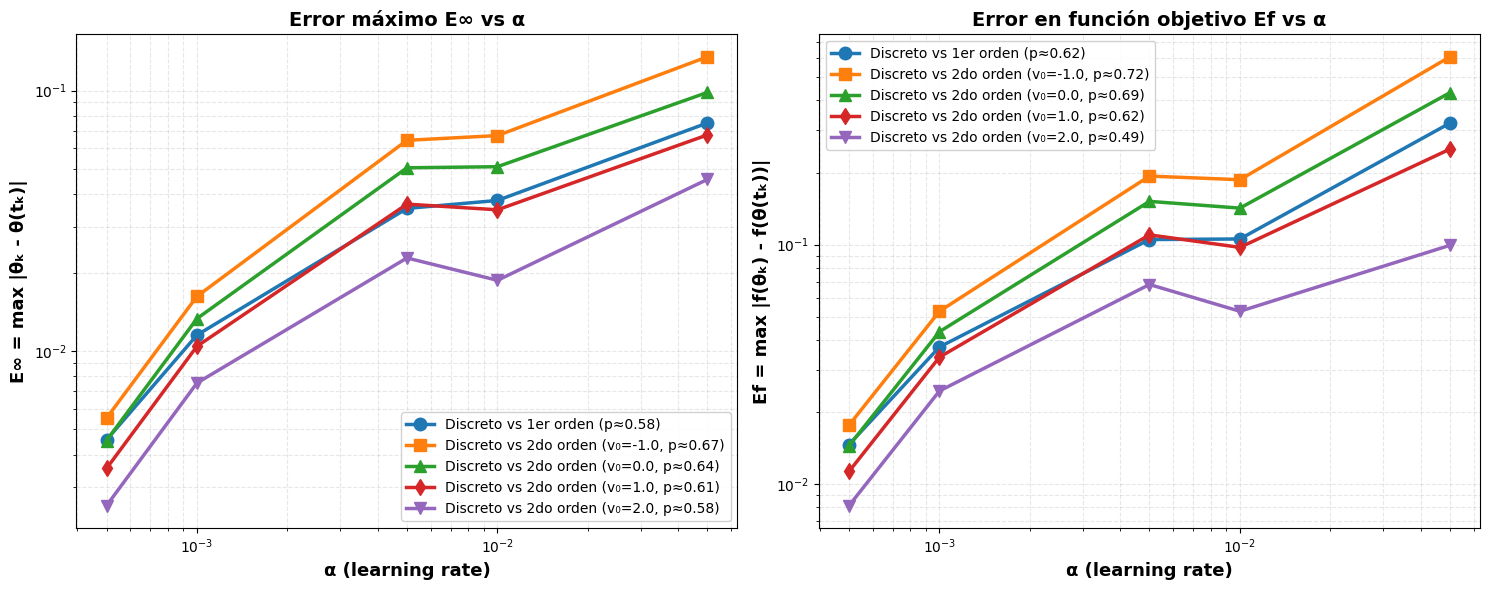

In [25]:
# Create log-log plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: E_inf(α)
ax1.loglog(
    lrs_1st, E_inf_1st,
    'o-',
    label=f'Discreto vs 1er orden (p≈{p_inf_1st:.2f})',
    linewidth=2.5, markersize=9, color='C0'
)

colors = ['C1', 'C2', 'C3', 'C4']
markers = ['s', '^', 'd', 'v']
for i, v0 in enumerate(sorted(E_inf_2nd_dict.keys())):
    ax1.loglog(
        lrs_2nd_dict[v0], E_inf_2nd_dict[v0],
        marker=markers[i % len(markers)], linestyle='-',
        label=f'Discreto vs 2do orden (v₀={v0}, p≈{p_inf_2nd[v0]:.2f})',
        linewidth=2.5, markersize=8, color=colors[i % len(colors)]
    )

ax1.set_xlabel('α (learning rate)', fontsize=13, fontweight='bold')
ax1.set_ylabel('E∞ = max |θₖ - θ(tₖ)|', fontsize=13, fontweight='bold')
ax1.set_title('Error máximo E∞ vs α', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10, loc='best', framealpha=0.9)
ax1.grid(True, alpha=0.3, which='both', linestyle='--')

# Plot 2: E_f(α)
ax2.loglog(
    lrs_1st, E_f_1st,
    'o-',
    label=f'Discreto vs 1er orden (p≈{p_f_1st:.2f})',
    linewidth=2.5, markersize=9, color='C0'
)

for i, v0 in enumerate(sorted(E_f_2nd_dict.keys())):
    ax2.loglog(
        lrs_2nd_dict[v0], E_f_2nd_dict[v0],
        marker=markers[i % len(markers)], linestyle='-',
        label=f'Discreto vs 2do orden (v₀={v0}, p≈{p_f_2nd[v0]:.2f})',
        linewidth=2.5, markersize=8, color=colors[i % len(colors)]
    )

ax2.set_xlabel('α (learning rate)', fontsize=13, fontweight='bold')
ax2.set_ylabel('Ef = max |f(θₖ) - f(θ(tₖ))|', fontsize=13, fontweight='bold')
ax2.set_title('Error en función objetivo Ef vs α', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10, loc='best', framealpha=0.9)
ax2.grid(True, alpha=0.3, which='both', linestyle='--')

plt.tight_layout()

Path("plots").mkdir(exist_ok=True, parents=True)
plt.savefig('plots/error_loglog_comparison.png', dpi=300, bbox_inches='tight')
print("\n✓ Gráficas guardadas en plots/error_loglog_comparison.png")
plt.show()